In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
torch.__version__

'2.5.1+cu121'

1.Data(preparing and loading)

In [3]:
#create known parameters
weight=0.7
bias=0.3

#create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X[:10],y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [4]:
#splitting the dataset into training and test(one of the most important concept in machine learning in general)
len(X),len(y)

(50, 50)

In [5]:
#create a train/test split
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

How might we visualize the data?

In [6]:
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    
    plt.figure(figsize=(10,7))
    #plot training data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label="training data")
    
    #plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="testing data")
    
    #are there predicitons?
    if predictions is not None:
        #plot the predicitons if they exist
        plt.scatter(test_data,predictions,c="r",s=4,label="predicitons")
        
    #show the legend
    
    plt.legend(prop={"size":14})

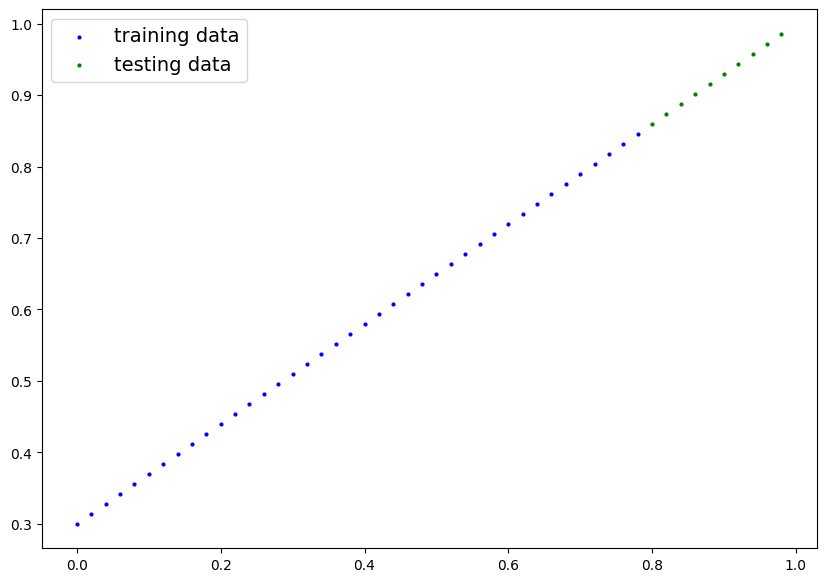

In [7]:
plot_prediction()

2.Build Model

In [8]:
#create linear regression model class

class LinearRegressionModel(nn.Module):#almost everything in pytorch inherhits from nn.module
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,
                                              requires_grad=True,
                                              dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))
        
        #forward method to define the computation in the model
    def forward(self,x:torch.Tensor)->torch.Tensor:#x is input data
        return self.weights*x+self.bias

In [9]:
#pytorch model building essentials
#torch.nn contains all the buildings for the computational graphs(a neural network can be considered a computautional graph)
#torch.nn.parameter-what parameters should our model try and learn,often a pytorch layer from torch.nn will set these for us
#torch.nn.module-the base class of all neural networks
#torch-optim-this where the optimizers in pytorch live,they will help with gradient descent
#def forward()-all nn.module subclasses require you to write forward(),this method defines what happens in the forward computation

In [10]:
#checking the contents of our model
#create a random seed

torch.manual_seed(42)

#create an instance of the model (this is a subclass of nn.module)
model_0=LinearRegressionModel()

#checkout the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
#list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [12]:
#making prediction using 'torch.inference_mode()'00_pytorch.ipynb

with torch.inference_mode():
    y_preds=model_0(X_test)
    

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
#you can also do something similar with torch.no_grad(),however,inference mode() is prefer
with torch.no_grad():
    y_preds=model_0(X_test)
    
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

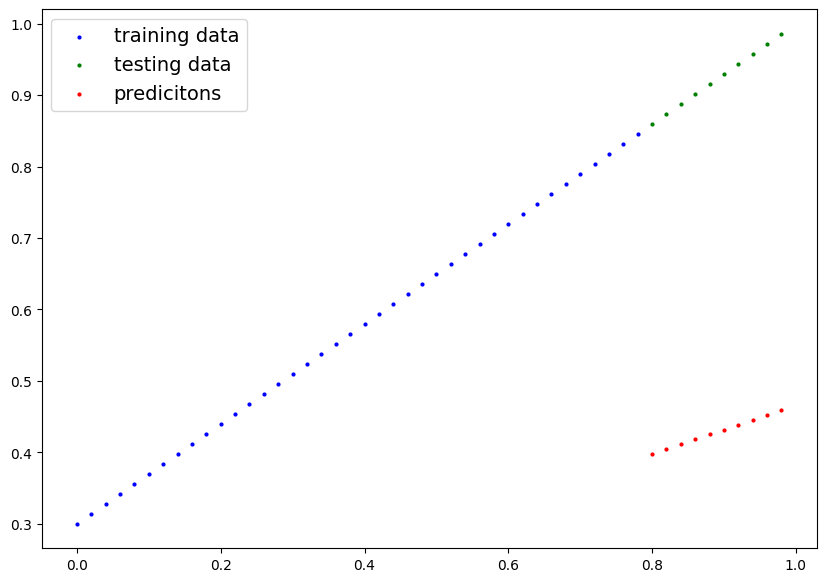

In [14]:
plot_prediction(predictions=y_preds)

3.Train Model

we use loss function to make better represenatation

In [15]:
#setup a loss function
loss_fn=nn.L1Loss()

#set up optimizer
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)#lr=learning rate

In [16]:
#building a training loop in pytorch
#an epoch is one loop through the data
epochs=10

#training
for epoch in range(epochs):
    #set the model to training mode
    model_0.train()#train mode in pytorch sets all parameters that require gradients to require gradients
    
    #1.forward pass
    y_pred=model_0(X_train)
    
    #2.calculate the loss
    loss=loss_fn(y_pred,y_train)
    print(f"Loss :{loss}")
    
    #3.optimizer zero grad
    optimizer.zero_grad()
    
    #4.perform backpropogation on the loss with respect to the parameters of the model
    loss.backward()
    
    #5.step the optimizer 
    optimizer.step()
    
    model_0.eval()#turn off gradient tracking
    
    #printout model state()
    print(model_0.state_dict())

Loss :0.31288138031959534
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss :0.3013603389263153
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
Loss :0.28983935713768005
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
Loss :0.2783183455467224
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
Loss :0.26679736375808716
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
Loss :0.2552763521671295
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
Loss :0.24375534057617188
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
Loss :0.23223432898521423
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
Loss :0.22071333229541779
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
Loss :0.20919232070446014
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})


In [17]:
with torch.inference_mode():
    y_preds_new=model_0(X_test)

In [18]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3757])), ('bias', tensor([0.2288]))])

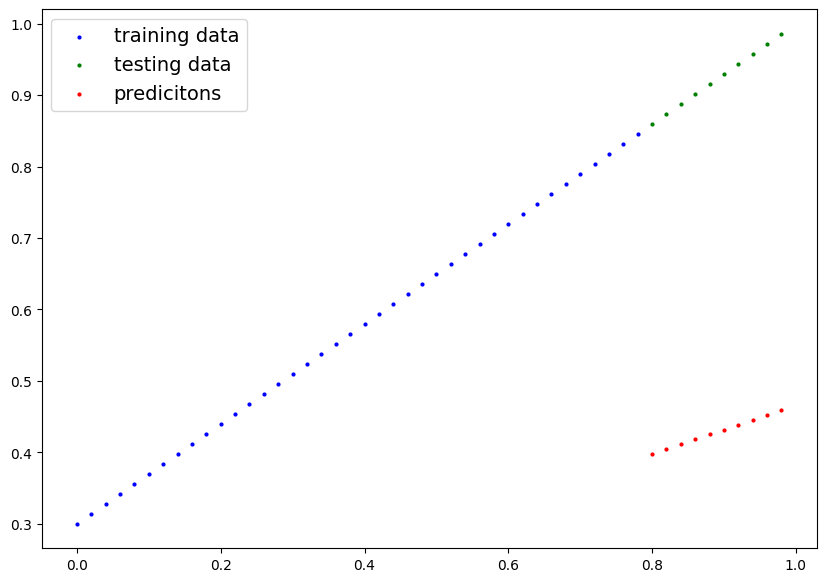

In [19]:
plot_prediction(predictions=y_preds)

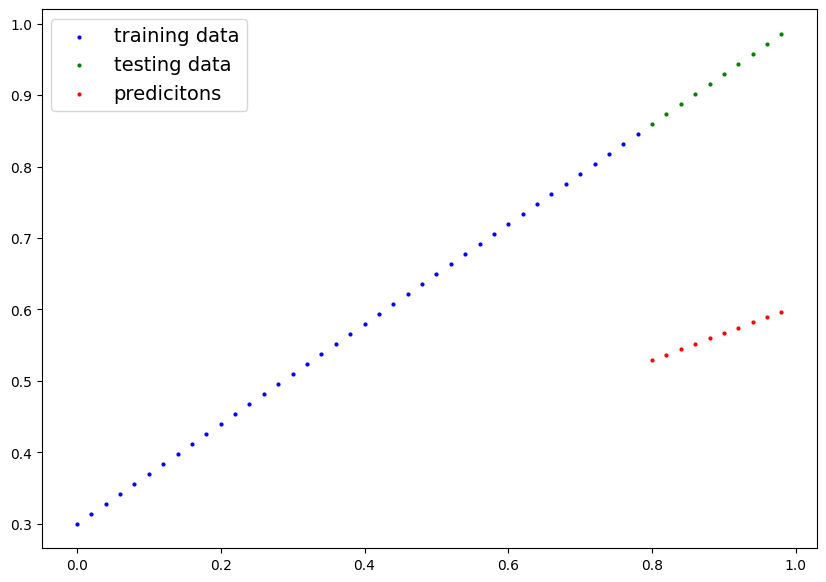

In [20]:
plot_prediction(predictions=y_preds_new)

4.Test the model

In [21]:
#building a training loop in pytorch
#an epoch is one loop through the data

torch.manual_seed(42)
epochs=200

#track different values
epoch_count=[]
loss_values=[]
test_loss_values=[]


#training
for epoch in range(epochs):
    #set the model to training mode
    model_0.train()#train mode in pytorch sets all parameters that require gradients to require gradients
    
    #1.forward pass
    y_pred=model_0(X_train)
    
    #2.calculate the loss
    loss=loss_fn(y_pred,y_train)
    print(f"Loss :{loss}")
    
    #3.optimizer zero grad
    optimizer.zero_grad()
    
    #4.perform backpropogation on the loss with respect to the parameters of the model
    loss.backward()
    
    #5.step the optimizer 
    optimizer.step()
    
    #testing
    model_0.eval()#turn off gradient tracking
    with torch.inference_mode():#turn off gradient tracking & a couple more things behind the scenes
        #1.do the forward pass
        test_pred=model_0(X_test)
        
        #2.calculate the loss
        test_loss=loss_fn(test_pred,y_test)
        
    if epoch%10==0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
    
    #print out what's happening
    print(f"epoch :{epoch} | loss:{loss} | test loss:{test_loss}")
    
    #printout model state()
    print(model_0.state_dict())

Loss :0.1976713240146637
epoch :0 | loss:0.1976713240146637 | test loss:0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Loss :0.18615034222602844
epoch :1 | loss:0.18615034222602844 | test loss:0.3328842222690582
OrderedDict({'weights': tensor([0.3835]), 'bias': tensor([0.2488])})
Loss :0.1746293306350708
epoch :2 | loss:0.1746293306350708 | test loss:0.3194132149219513
OrderedDict({'weights': tensor([0.3874]), 'bias': tensor([0.2588])})
Loss :0.16310831904411316
epoch :3 | loss:0.16310831904411316 | test loss:0.30594223737716675
OrderedDict({'weights': tensor([0.3913]), 'bias': tensor([0.2688])})
Loss :0.1515873372554779
epoch :4 | loss:0.1515873372554779 | test loss:0.2924712300300598
OrderedDict({'weights': tensor([0.3952]), 'bias': tensor([0.2788])})
Loss :0.14006635546684265
epoch :5 | loss:0.14006635546684265 | test loss:0.27900025248527527
OrderedDict({'weights': tensor([0.3991]), 'bias': tensor([0.2888])})
Loss :0.1285453587770462
epoch :

In [22]:
with torch.inference_mode():
    y_pred_new=model_0(X_test)

In [23]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

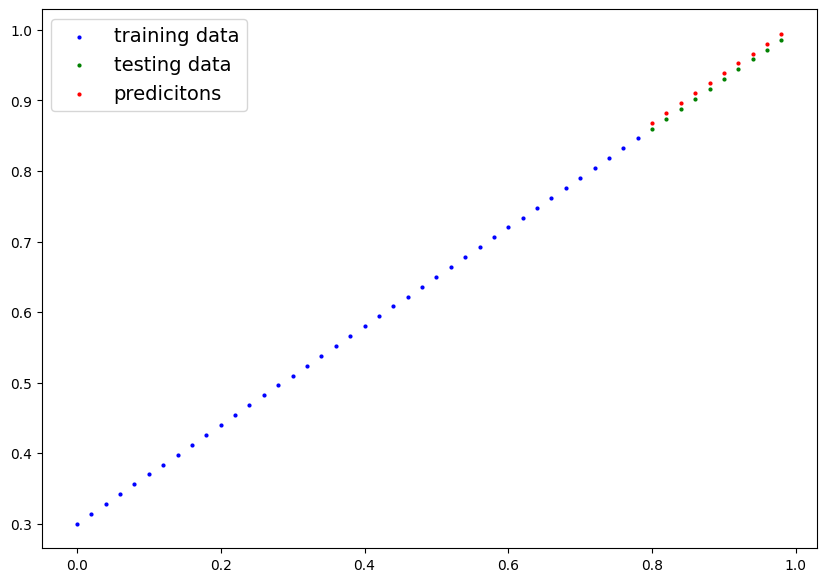

In [24]:
plot_prediction(predictions=y_pred_new)

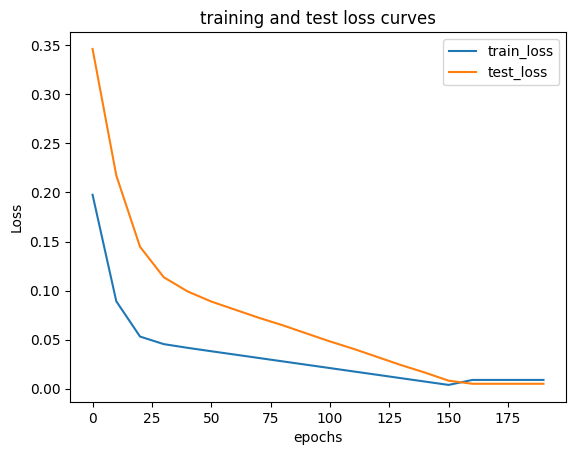

In [25]:
#plot the loss curves
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="train_loss")
plt.plot(epoch_count,test_loss_values,label="test_loss")
plt.title("training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("epochs")
plt.legend()

5.Save and Load model

In [26]:
#saving a model in pytorch
#three main methods 
#1.torch.save()-allows you to save the model in pickle format
#2.torch.load()-aloows you to load a saved pytorch model
#3.torch.nn.Module.load_state_dict()-this allows to load a model;s saved state dictoinary

from pathlib import Path

#1.create model directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2.create model save path
MODEL_NAME="04_pytorch.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

#3.save the model state dict
print(f"saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to :models\04_pytorch.pth


In [27]:
model_0

LinearRegressionModel()

In [28]:
ls -l models

 Volume in drive C is ACER
 Volume Serial Number is 9467-634A

 Directory of c:\Users\Omkar Kadam\Desktop\PyTorch


 Directory of c:\Users\Omkar Kadam\Desktop\PyTorch\models

28-03-2026  12:26    <DIR>          .
24-03-2026  11:47    <DIR>          ..
29-03-2026  11:04             1,514 04_pytorch.pth
28-03-2026  12:26             1,584 04_pytorch1.pth
               2 File(s)          3,098 bytes
               2 Dir(s)  340,117,573,632 bytes free


File Not Found


In [29]:
#loading a pytorch model
#since we saved our model state_dict,we'll create a new instance of our model class and load the saved
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [30]:
#to load in saved_dict  we have to instantiate a new instance of our model class
loaded_model_0=LinearRegressionModel()

#to load a saved dict mof model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\Omkar Kadam\AppData\Local\Temp\ipykernel_20108\486502087.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_

<All keys matched successfully>

In [31]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [32]:
#make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds=loaded_model_0(X_test)
    
loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [33]:
#compare loaded model preds with originial model preds
y_preds==loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

6.Putting all it together

In [34]:
#setup device agnostic mode
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [35]:
!nvidia-smi

Sun Mar 29 11:04:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.93                 Driver Version: 576.93         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   39C    P8              6W /   30W |      62MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
#6.1 data
#create some data using linear regression formula of y=weight*x+bias
weight=0.7
bias=0.3

#create range values
start=0
end=1
step=0.02

#create X and y(features and labels)
X=torch.arange(start,end,step).unsqueeze(dim=1)#without unsqueeze,errors will pop up
y=weight*X+bias
X[:10],y[:10]



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [37]:
#split the data
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)


(40, 40, 10, 10)

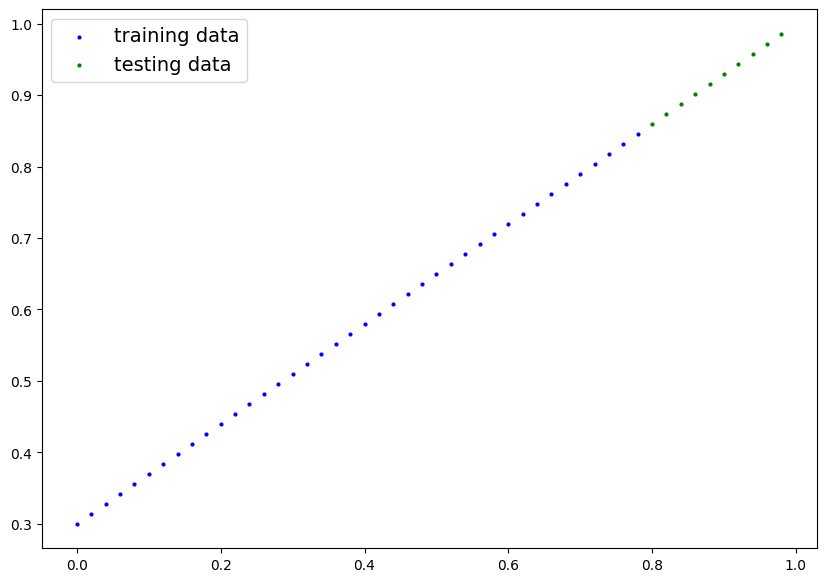

In [38]:
#plot the data
#note:if you don't have the plot_predictions() functions loaded,this will error
plot_prediction(X_train,y_train,X_test,y_test)

In [39]:
#6.2 building a pytorch linear model
#create a linear model by subclassing nn.module
class linearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        #use nn.linear() for creating the model parameters/also called:linear transforms
        self.linear_layer=nn.Linear(in_features=1,out_features=1)
        
    
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear_layer(x)
    
#set the manual seed
torch.manual_seed(42)
model_1=linearRegressionModelV2()
model_1,model_1.state_dict()

(linearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [40]:
next(model_1.parameters()).device

device(type='cpu')

In [41]:
#set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [42]:
#6.3 training 
#for training we need
#loss function,training loop,testing loop

#setup a loss function
loss_fn=nn.L1Loss() #same as MAE

#setup the optimizer
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.01,)

In [43]:
#let's write a training loop
torch.manual_seed(42)

epochs=200
#put data on the target device 
X_train=X_train.to(device)
y_train=y_train.to(device)
X_test=X_test.to(device)
y_test=y_test.to(device)
for epoch in range(epochs):
    model_1.train()
    
    #1.forward pass
    y_pred=model_1(X_train)
    
    #2.calculate the loss
    loss=loss_fn(y_pred,y_train)
    
    #3.optimize zero grad
    optimizer.zero_grad()
    
    #4.perform backpropogation
    loss.backward()
    
    #5.optimizer step
    optimizer.step()
    
    #testing
    model_1.eval()
    
    with torch.inference_mode():
        test_pred=model_1(X_test)
        
        test_loss=loss_fn(test_pred,y_test)
        
    #print out what's happenening
    if epoch%10==0:
        print(f"epoch:{epoch}, loss:{loss},test_loss:{test_loss}")
    
    
    

epoch:0, loss:0.5551779866218567,test_loss:0.5739762187004089
epoch:10, loss:0.439968079328537,test_loss:0.4392664134502411
epoch:20, loss:0.3247582018375397,test_loss:0.30455657839775085
epoch:30, loss:0.20954833924770355,test_loss:0.16984669864177704
epoch:40, loss:0.09433845430612564,test_loss:0.03513690456748009
epoch:50, loss:0.023886388167738914,test_loss:0.04784907028079033
epoch:60, loss:0.019956795498728752,test_loss:0.045803118497133255
epoch:70, loss:0.016517987474799156,test_loss:0.037530567497015
epoch:80, loss:0.013089174404740334,test_loss:0.02994490973651409
epoch:90, loss:0.009653178043663502,test_loss:0.02167237363755703
epoch:100, loss:0.006215683650225401,test_loss:0.014086711220443249
epoch:110, loss:0.00278724217787385,test_loss:0.005814164876937866
epoch:120, loss:0.0012645035749301314,test_loss:0.013801801018416882
epoch:130, loss:0.0012645035749301314,test_loss:0.013801801018416882
epoch:140, loss:0.0012645035749301314,test_loss:0.013801801018416882
epoch:150, 

In [44]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [45]:
weight,bias

(0.7, 0.3)

In [46]:
#6.4 turn model into evaluation mode
model_1.eval()

#make predictions on the test data
with torch.inference_mode():
    y_preds=model_1(X_test)
    
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

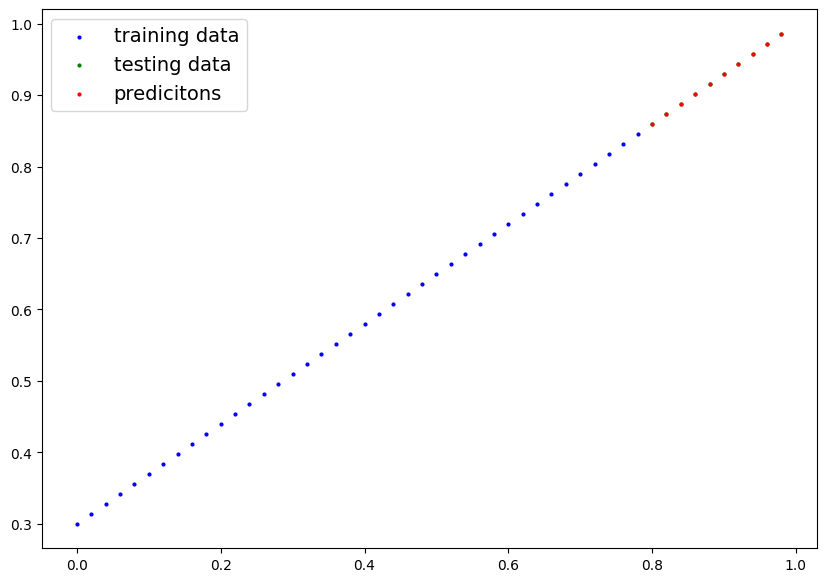

In [47]:
#check out our model predictions visually
plot_prediction(predictions=y_preds.cpu())

In [48]:
#saving and loading the model
from pathlib import Path
#create a model direcrtory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#create model save path
MODEL_NAME="04_pytorch1.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

#save the model state dict
print(f"saving the model to :{MODEL_SAVE_PATH}")

torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

saving the model to :models\04_pytorch1.pth


In [49]:
#load the model

#create a new instance of linear regression model V2
loaded_model_1=linearRegressionModelV2()

#load the saved model_1.state_dict()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

#put the loaded model to device
loaded_model_1.to(device)

C:\Users\Omkar Kadam\AppData\Local\Temp\ipykernel_20108\3668287401.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_P

linearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)